# CSCI8350 Graduate Project
Emily Uehling and Troy Gilmore

Rice Paddy Yield Dataset and Modeling

## Import Packages

In [95]:
# Imports
import pandas as pd
import numpy as np
import csv
import os, time
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import re
import scipy as sp
from scipy import stats
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier #, GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# import graphviz
from sklearn import tree
# import pydotplus
from IPython.display import Image, display

In [96]:
# Data source: Subramaniyan, M. (2023). Paddy Dataset [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55W3J.
# Define path for full dataset
data = Path("Data/paddydataset.csv")

# Import
df = pd.read_csv(data)

# Strip any extraneous white spaces, etc.
df.columns = df.columns.str.strip()
columns = df.columns

# List column names and basic info
print("Columns:", columns)
print("Number of Columns:", len(df.columns))
print("Shape of full CSV Import:", df.shape)

Columns: Index(['Hectares', 'Agriblock', 'Variety', 'Soil Types', 'Seedrate(in Kg)',
       'LP_Mainfield(in Tonnes)', 'Nursery', 'Nursery area (Cents)',
       'LP_nurseryarea(in Tonnes)', 'DAP_20days', 'Weed28D_thiobencarb',
       'Urea_40Days', 'Potassh_50Days', 'Micronutrients_70Days',
       'Pest_60Day(in ml)', '30DRain( in mm)', '30DAI(in mm)',
       '30_50DRain( in mm)', '30_50DAI(in mm)', '51_70DRain(in mm)',
       '51_70AI(in mm)', '71_105DRain(in mm)', '71_105DAI(in mm)',
       'Min temp_D1_D30', 'Max temp_D1_D30', 'Min temp_D31_D60',
       'Max temp_D31_D60', 'Min temp_D61_D90', 'Max temp_D61_D90',
       'Min temp_D91_D120', 'Max temp_D91_D120',
       'Inst Wind Speed_D1_D30(in Knots)', 'Inst Wind Speed_D31_D60(in Knots)',
       'Inst Wind Speed_D61_D90(in Knots)',
       'Inst Wind Speed_D91_D120(in Knots)', 'Wind Direction_D1_D30',
       'Wind Direction_D31_D60', 'Wind Direction_D61_D90',
       'Wind Direction_D91_D120', 'Relative Humidity_D1_D30',
       'Relat

In [97]:
# Print column data type, number of unique values, and number of missing values
data_summary = pd.DataFrame({
    "Data Type": df[columns].dtypes,
    "Unique Values": [df[col].nunique() for col in columns],
    "Missing Values": [df[col].isna().sum() for col in columns]
})

print(data_summary)

# List number of non-numeric columns
object_columns = df.select_dtypes(include=['object']).columns
print("Number of Categorical Columns:", object_columns.shape[0])
print("Categorical Columns:", object_columns)

                                   Data Type  Unique Values  Missing Values
Hectares                               int64              6               0
Agriblock                                str              6               0
Variety                                  str              3               0
Soil Types                               str              2               0
Seedrate(in Kg)                        int64              6               0
LP_Mainfield(in Tonnes)              float64              6               0
Nursery                                  str              2               0
Nursery area (Cents)                   int64              6               0
LP_nurseryarea(in Tonnes)              int64              6               0
DAP_20days                             int64              6               0
Weed28D_thiobencarb                    int64              6               0
Urea_40Days                          float64              6               0
Potassh_50Da

C:\Users\emily\AppData\Local\Temp\ipykernel_15284\2171019109.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes(include=['object']).columns


#### Encode to explore
This simple ordinal encoding is to allow data exploration.
Encoding for ML, mining, will be done later using one-hot encoding.

In [98]:
# https://www.geeksforgeeks.org/machine-learning/encoding-categorical-data-in-sklearn/
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in object_columns:
    df[col + '_encoded'] = le.fit_transform(df[col])
    print("Class labels mapping:", dict(zip(le.classes_, le.transform(le.classes_)))) #Show numeric values assigned to classes

df_clean = df.drop(columns=[col for col in df.columns if col in object_columns])

Class labels mapping: {'Chinnasalem': np.int64(0), 'Cuddalore': np.int64(1), 'Kallakurichi': np.int64(2), 'Kurinjipadi': np.int64(3), 'Panruti': np.int64(4), 'Sankarapuram': np.int64(5)}
Class labels mapping: {'CO_43': np.int64(0), 'delux ponni': np.int64(1), 'ponmani': np.int64(2)}
Class labels mapping: {'alluvial': np.int64(0), 'clay': np.int64(1)}
Class labels mapping: {'dry': np.int64(0), 'wet': np.int64(1)}
Class labels mapping: {'E': np.int64(0), 'ENE': np.int64(1), 'NW': np.int64(2), 'SSE': np.int64(3), 'SW': np.int64(4), 'W': np.int64(5)}
Class labels mapping: {'ENE': np.int64(0), 'NE': np.int64(1), 'S': np.int64(2), 'W': np.int64(3), 'WNW': np.int64(4)}
Class labels mapping: {'NE': np.int64(0), 'NNE': np.int64(1), 'NNW': np.int64(2), 'SE': np.int64(3), 'SW': np.int64(4)}
Class labels mapping: {'NNW': np.int64(0), 'NW': np.int64(1), 'S': np.int64(2), 'SSE': np.int64(3), 'W': np.int64(4), 'WSW': np.int64(5)}


In [99]:
# Check for duplicate rows
print(df_clean.shape)
print("Number of Duplicate Rows: ", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print(df_clean.shape)

(2789, 45)
Number of Duplicate Rows:  451
(2338, 45)


In [100]:
# Calculate basic statistics for all features
# Values with "_encoded" appended are categorical variables, ordinal encoded
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Hectares,2338.0,3.736099,1.450388,1.00,3.00,4.00,5.00,6.00
Seedrate(in Kg),2338.0,93.402481,36.259703,25.00,75.00,100.00,125.00,150.00
LP_Mainfield(in Tonnes),2338.0,46.701240,18.129851,12.50,37.50,50.00,62.50,75.00
Nursery area (Cents),2338.0,74.721985,29.007762,20.00,60.00,80.00,100.00,120.00
LP_nurseryarea(in Tonnes),2338.0,3.736099,1.450388,1.00,3.00,4.00,5.00,6.00
DAP_20days,2338.0,149.443969,58.015525,40.00,120.00,160.00,200.00,240.00
Weed28D_thiobencarb,2338.0,7.472198,2.900776,2.00,6.00,8.00,10.00,12.00
Urea_40Days,2338.0,101.360372,39.349030,27.13,81.39,108.52,135.65,162.78
Potassh_50Days,2338.0,38.780710,15.055029,10.38,31.14,41.52,51.90,62.28
Micronutrients_70Days,2338.0,56.041488,21.755822,15.00,45.00,60.00,75.00,90.00


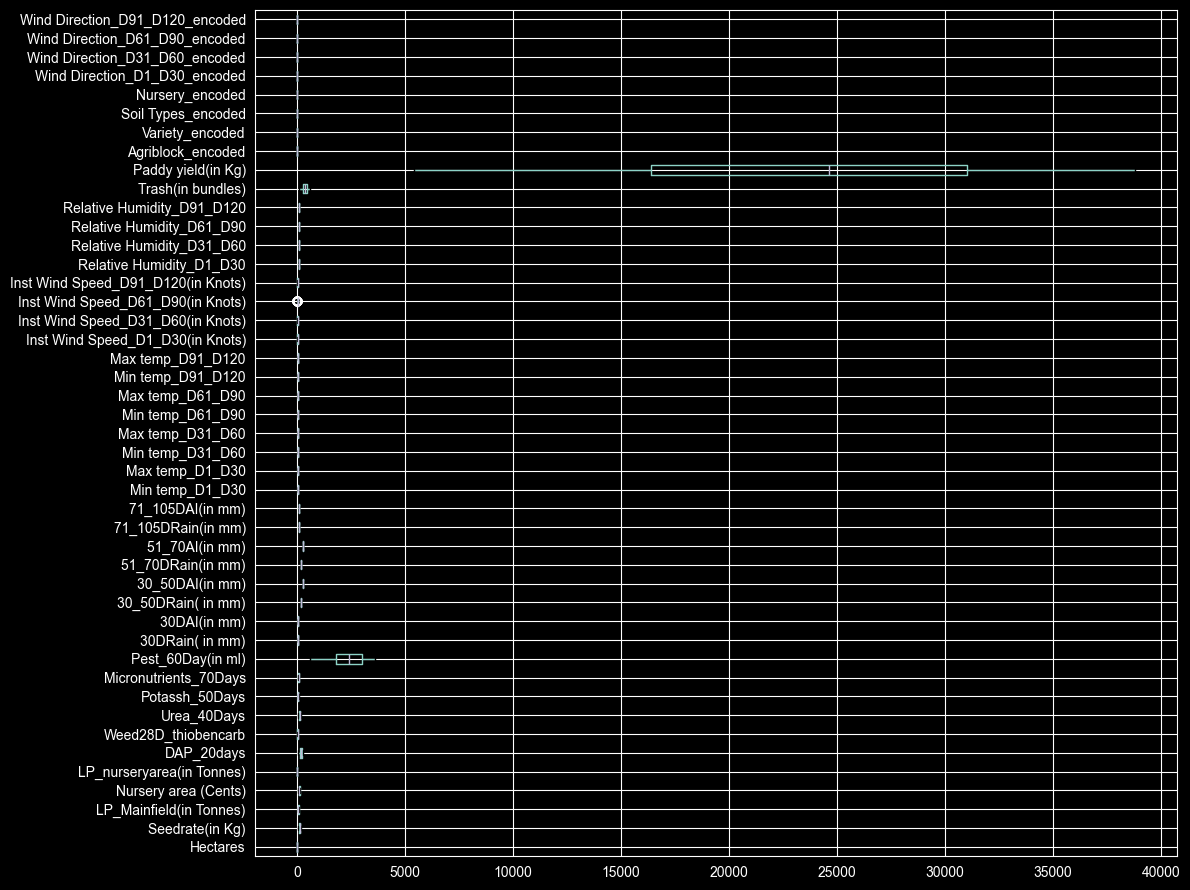

In [101]:
# Horizontal boxplot of all features
plt.figure(figsize=(12, 9))
df_clean.boxplot(vert=False)
plt.tight_layout()
plt.show()

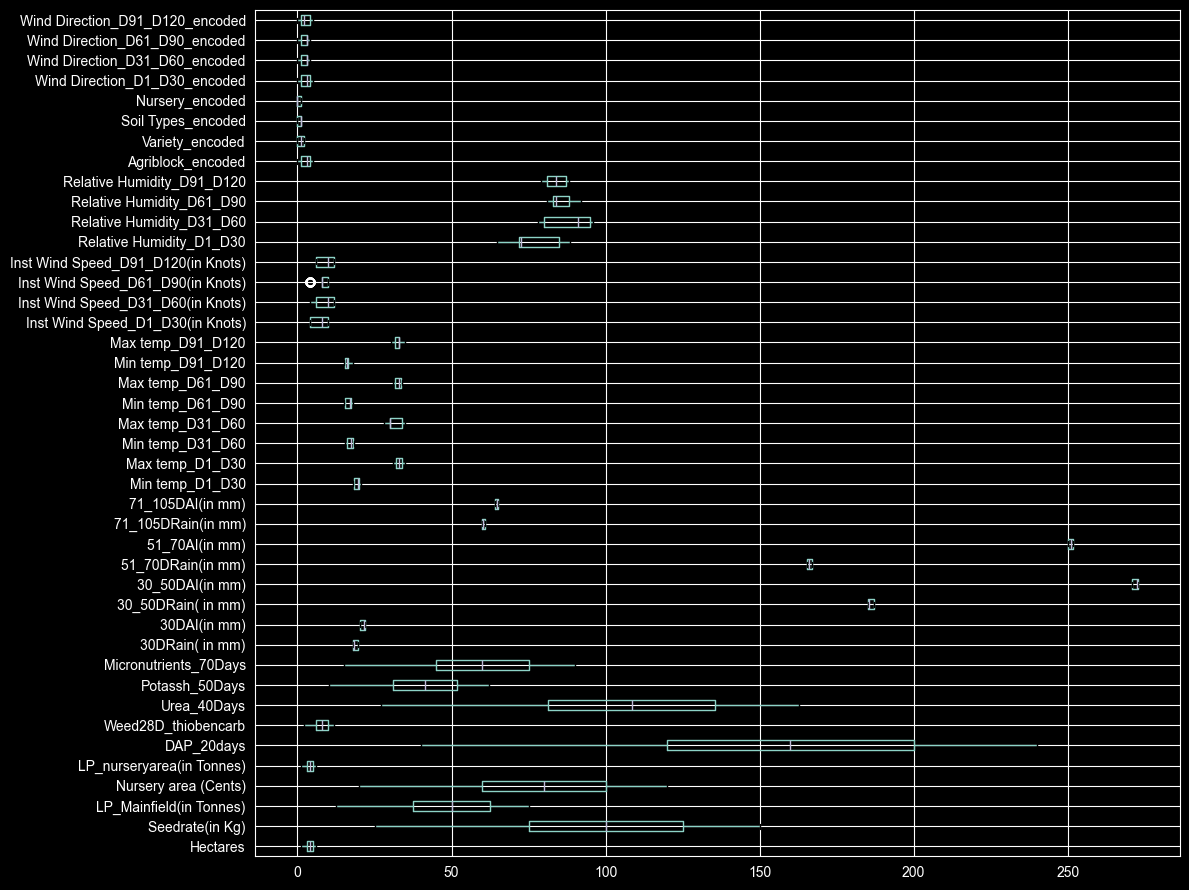

In [102]:
# Horizontal plot for all columns except paddy yield and pesticide info (they are large and obscure other data)
df_clean_no_yield_pest_trash = df_clean.drop(
    columns=['Paddy yield(in Kg)', 'Pest_60Day(in ml)', 'Trash(in bundles)'])

# print(df_clean_no_yield_no_pest.columns)
plt.figure(figsize=(12, 9))
df_clean_no_yield_pest_trash.boxplot(vert=False)
plt.tight_layout()
plt.show()

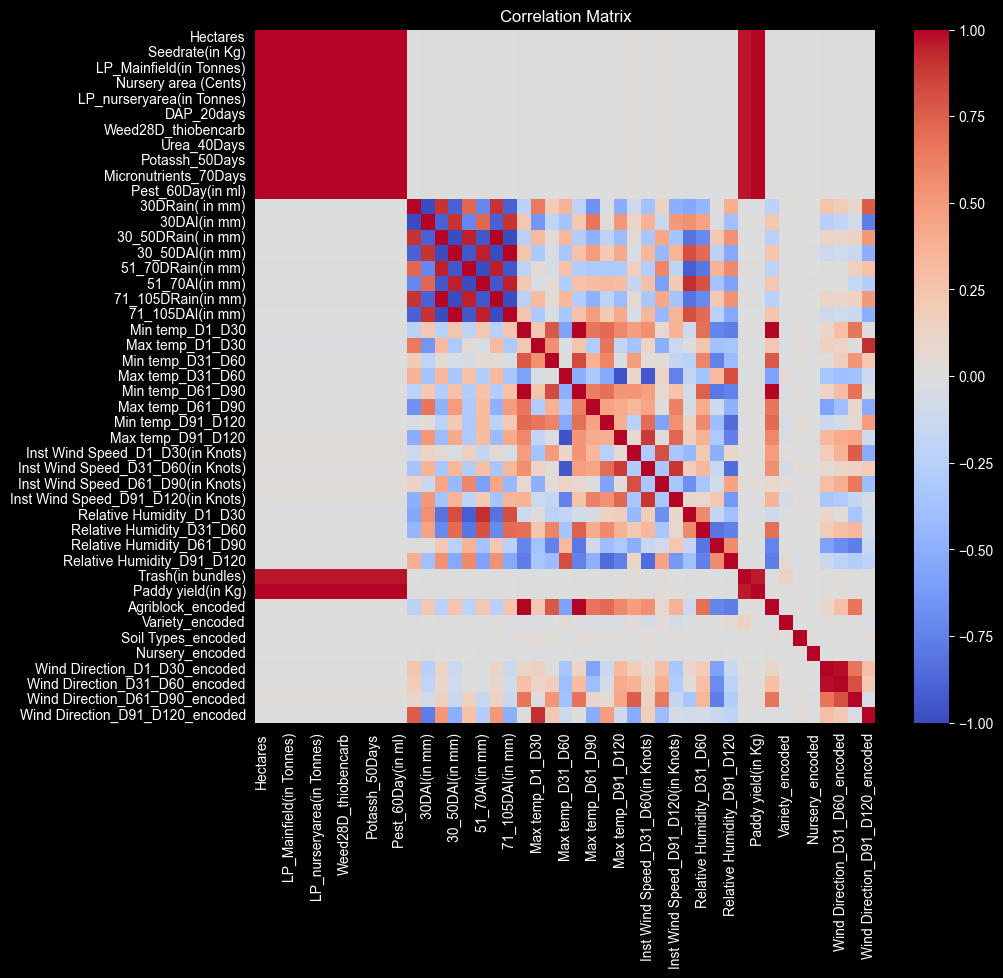

In [103]:
# Preliminary correlation plot
corr = df_clean.select_dtypes(include='number').corr()
plt.figure(figsize=(10, 9))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

## Create Yield per Hectare variable and remove some variables

In [104]:
# Yield per hectare is more consistent with research on crop yields
# Normalizing by paddy area
df_clean['Yield per Hectare'] = df_clean['Paddy yield(in Kg)']/df_clean['Hectares']

# Drop features that were perfectly correlated with paddy area (Hectares)
df_clean = df_clean.drop(columns = ['LP_Mainfield(in Tonnes)', 
                                    'LP_nurseryarea(in Tonnes)', 
                                    'Nursery area (Cents)',
                                    'Paddy yield(in Kg)'
                                   ])

In [105]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.describe.html#scipy.stats.describe

cols = df_clean.select_dtypes(include="number").columns

summary_stats = pd.DataFrame({
    "nobs": [stats.describe(df_clean[col]).nobs for col in cols],
    "min": [stats.describe(df_clean[col]).minmax[0] for col in cols],
    "max": [stats.describe(df_clean[col]).minmax[1] for col in cols],
    "mean": [stats.describe(df_clean[col]).mean for col in cols],
    "variance": [stats.describe(df_clean[col]).variance for col in cols],
    "skewness": [stats.describe(df_clean[col]).skewness for col in cols],
    "kurtosis": [stats.describe(df_clean[col]).kurtosis for col in cols],
}, index=cols)

summary_stats

,nobs,min,max,mean,variance,skewness,kurtosis
Hectares,2338,1.00,6.00,3.736099,2.103626,-0.356003,-0.915293
Seedrate(in Kg),2338,25.00,150.00,93.402481,1314.766053,-0.356003,-0.915293
DAP_20days,2338,40.00,240.00,149.443969,3365.801095,-0.356003,-0.915293
Weed28D_thiobencarb,2338,2.00,12.00,7.472198,8.414503,-0.356003,-0.915293
Urea_40Days,2338,27.13,162.78,101.360372,1548.346128,-0.356003,-0.915293
Potassh_50Days,2338,10.38,62.28,38.780710,226.653887,-0.356003,-0.915293
Micronutrients_70Days,2338,15.00,90.00,56.041488,473.315779,-0.356003,-0.915293
Pest_60Day(in ml),2338,600.00,3600.00,2241.659538,757305.246467,-0.356003,-0.915293
30DRain( in mm),2338,18.10,19.60,18.712789,0.409665,0.537806,-1.477915
30DAI(in mm),2338,20.40,21.90,21.287211,0.409665,-0.537806,-1.477915


### Normalize all data
Use min-max scaler to normalize and plot data.

(2338, 42)
Number of Duplicate Rows:  0
(2338, 42)


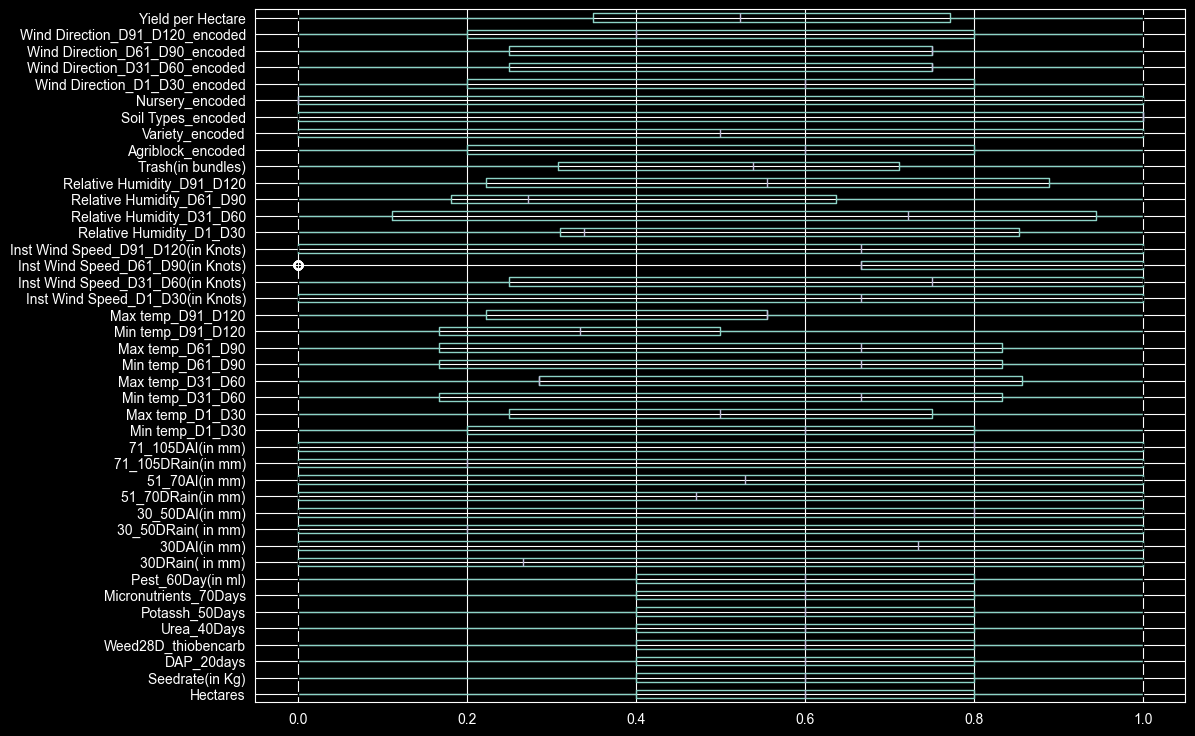

In [106]:
# Use min-max scaler to normalize data
scaler = MinMaxScaler()

df_normalized = pd.DataFrame(
    scaler.fit_transform(df_clean),
    columns=df_clean.columns,
    index=df_clean.index
)

# Check for duplicate rows (some rows could have same values after normalizing)
print(df_normalized.shape)
print("Number of Duplicate Rows: ", df_normalized.duplicated().sum())
df_normalized = df_normalized.drop_duplicates()
print(df_normalized.shape)

# Quick plot for all columns, normalized data
plt.figure(figsize=(12, 9))
plt.tight_layout()
df_normalized.boxplot(vert=False)
plt.show()

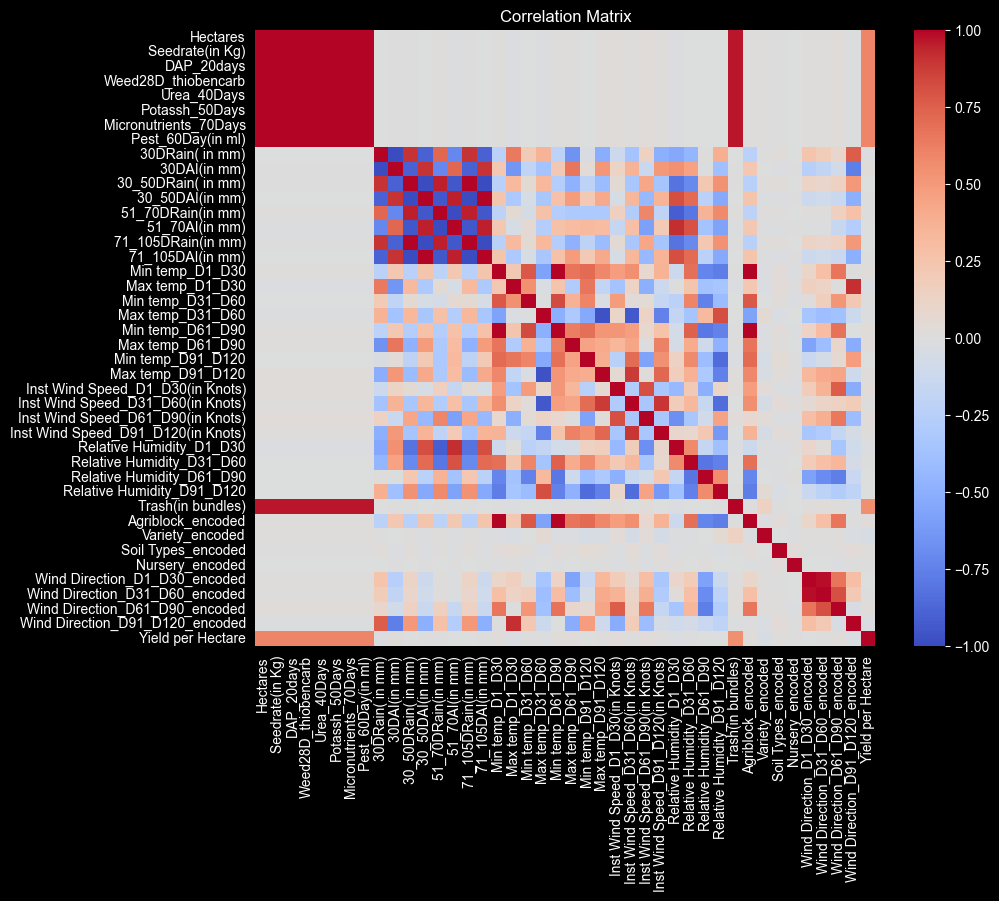

In [107]:
corr = df_clean.select_dtypes(include='number').corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

In [108]:
# Note that Hectares variable is strongly correlated with yield
# Get a relative yield value, assuming that the paddies are different size
# This gives yield per Hectare instead of just yield 
# df_clean['Yield per Hectare'] = df_clean['Paddy yield(in Kg)']/df_clean['Hectares']

# Min-max scaling again, to include new feature

# scaler = MinMaxScaler()

# df_normalized = pd.DataFrame(
#     scaler.fit_transform(df_clean),
#     columns=df_clean.columns,
#     index=df_clean.index
# )

# print(df_normalized.head(5))

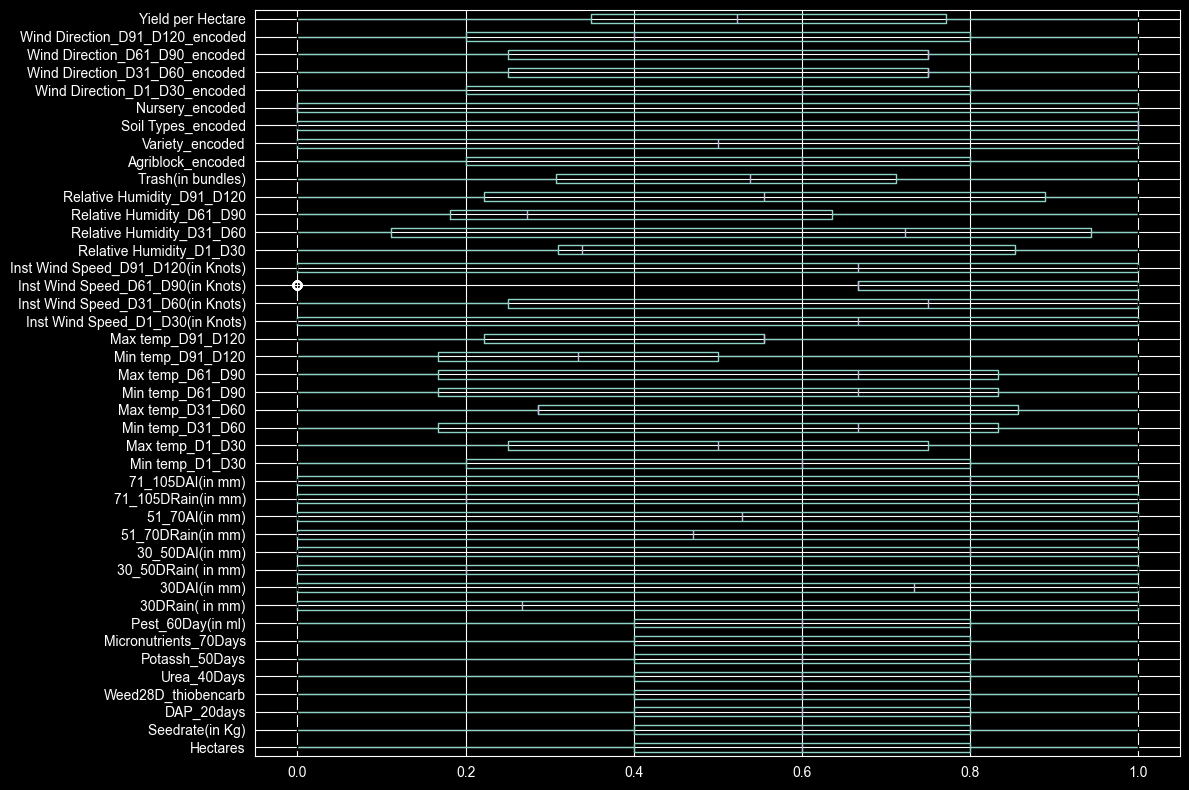

In [109]:
# Horizontal boxplot of normalized (min-max scaling) features
plt.figure(figsize=(12, 8))
df_normalized.boxplot(vert=False)
plt.tight_layout()
plt.show()

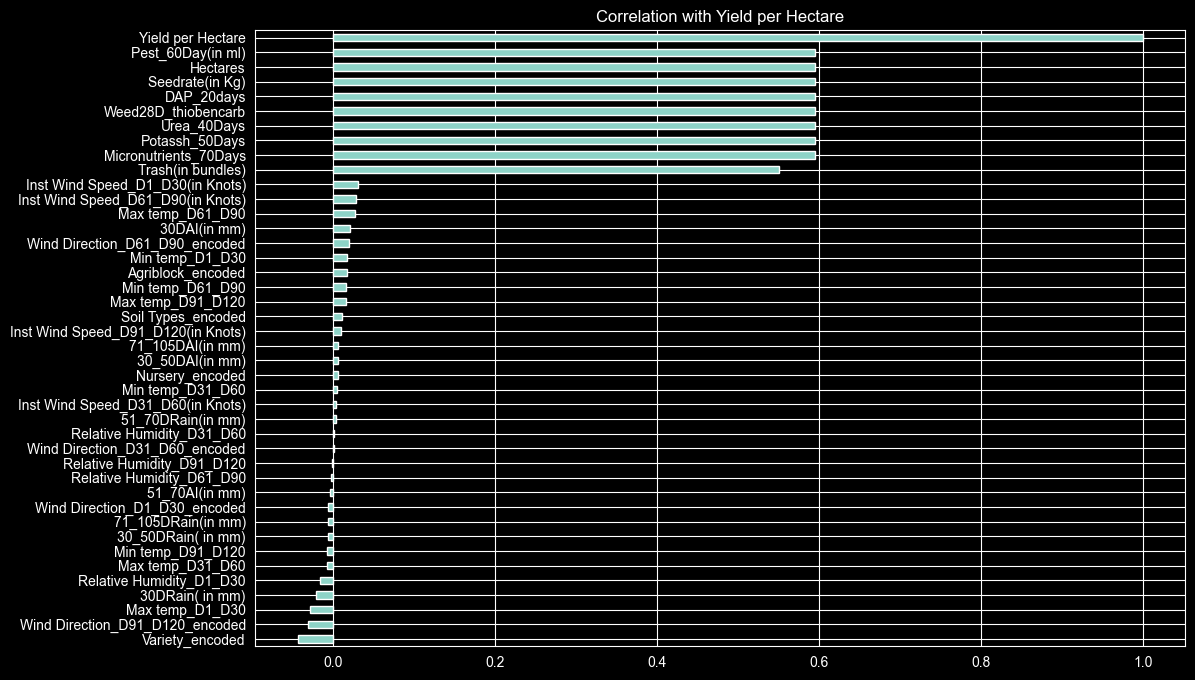

In [110]:
# Show correlation with response variable
plt.figure(figsize=(12, 8))
plt.tight_layout()

target = 'Yield per Hectare'

corr_target = df_normalized.select_dtypes(include='number').corr()[target].sort_values()

corr_target.plot(kind='barh')
plt.title(f"Correlation with {target}")
plt.show()

# Prepare Dataset for Modeling
+ return to original df
+ remove features (based on exploration, above)
+ create classes for response variable
+ create df for modeling

In [111]:
# Data source: Subramaniyan, M. (2023). Paddy Dataset [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55W3J.
# Define path for full dataset
data = Path("Data/paddydataset.csv")
# Import
df = pd.read_csv(data)

# Strip any extraneous white spaces, etc.
df.columns = df.columns.str.strip()

# Create df for modeling
df_for_modeling = df

# Create yield per hectare column in original df
df_for_modeling['Yield per Hectare'] = df_for_modeling['Paddy yield(in Kg)']/df['Hectares']

# Drop Hectares and Paddy Yield (in Kg) column from original dataset
df_for_modeling = df.drop(columns = ['LP_Mainfield(in Tonnes)', 
                                    'LP_nurseryarea(in Tonnes)', 
                                    'Nursery area (Cents)',
                                    'Paddy yield(in Kg)'
                                   ])

# Create bins for Yield per Hectare, to set up for classification (rather than regression)
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html
# https://www.geeksforgeeks.org/python/how-to-use-pandas-cut-and-qcut/
df_for_modeling['Yield Per Hectare Class'] = pd.qcut(df_for_modeling['Yield per Hectare'], 
                                         q=3, 
                                         labels=['Low', 'Medium', 'High'])

# Check whether low to high are consistent with actual numerical values
print(df_for_modeling['Yield Per Hectare Class'])

# Drop Hectares and Paddy Yield (in Kg) column from non-normalized, clean dataset
# df_for_modeling = df_for_modeling.drop(columns = ['Yield per Hectare'])
# Drop raw yield per hectare after binning — keeping it would leak the target into the features

print(df_for_modeling.shape)
print(df_for_modeling.columns)

0          Low
1       Medium
2       Medium
3          Low
4          Low
         ...  
2784       Low
2785       Low
2786       Low
2787    Medium
2788    Medium
Name: Yield Per Hectare Class, Length: 2789, dtype: category
Categories (3, str): ['Low' < 'Medium' < 'High']
(2789, 43)
Index(['Hectares', 'Agriblock', 'Variety', 'Soil Types', 'Seedrate(in Kg)',
       'Nursery', 'DAP_20days', 'Weed28D_thiobencarb', 'Urea_40Days',
       'Potassh_50Days', 'Micronutrients_70Days', 'Pest_60Day(in ml)',
       '30DRain( in mm)', '30DAI(in mm)', '30_50DRain( in mm)',
       '30_50DAI(in mm)', '51_70DRain(in mm)', '51_70AI(in mm)',
       '71_105DRain(in mm)', '71_105DAI(in mm)', 'Min temp_D1_D30',
       'Max temp_D1_D30', 'Min temp_D31_D60', 'Max temp_D31_D60',
       'Min temp_D61_D90', 'Max temp_D61_D90', 'Min temp_D91_D120',
       'Max temp_D91_D120', 'Inst Wind Speed_D1_D30(in Knots)',
       'Inst Wind Speed_D31_D60(in Knots)',
       'Inst Wind Speed_D61_D90(in Knots)',
       'Inst W

### Define Utility Functions (from past homework/class)

In [112]:
# Define utility functions
# This code from Applied ML Course by Christian Haas, UNO

def evaluate_regression_model(model, X, y, model_name="Model"):
    """
    Evaluate regression model and return metrics
    """
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    
    print(f"{model_name} Performance:")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R﷿﷿ Score: {r2:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    
    return {'rmse': rmse, 'r2': r2, 'mae': mae}

# ============================================================
# This is code for binary classification
# Was modified to accommodate multi-class for grad project
# ============================================================

# def evaluate_classification_model(model, X, y, y_prob=None, model_name="Model"):
#     """
#     Evaluate classification model and return metrics
#     """
#     y_pred = model.predict(X)
#     if y_prob is None and hasattr(model, "predict_proba"):
#         y_prob = model.predict_proba(X)[:, 1]
    
#     accuracy = accuracy_score(y, y_pred)
    
#     metrics = {
#         'accuracy': accuracy,
#     }
    
#     print(f"{model_name} Performance:")
#     print(f"Accuracy: {accuracy:.4f}")
    
#     if y_prob is not None:
#         roc_auc = roc_auc_score(y, y_prob)
#         metrics['roc_auc'] = roc_auc
#         print(f"ROC AUC: {roc_auc:.4f}")
    
#     # Print confusion matrix
#     cm = confusion_matrix(y, y_pred)
#     print("\nConfusion Matrix:")
#     print(cm)
    
#     # Print classification report
#     print("\nClassification Report:")
#     print(classification_report(y, y_pred))
    
#     return metrics

def evaluate_classification_model(model, X, y, y_prob, model_name):
    metrics = {}

    # Predictions
    y_pred = model.predict(X)

    # Accuracy
    accuracy = accuracy_score(y, y_pred)
    metrics['accuracy'] = accuracy

    print(f"\n{model_name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")

    # Multiclass ROC AUC (OvR)
    if y_prob is not None:
        roc_auc = roc_auc_score(
            y,
            y_prob,
            multi_class='ovr',
            average='macro'
        )
        metrics['roc_auc_ovr_macro'] = roc_auc
        print(f"ROC AUC (OvR, macro): {roc_auc:.4f}")

    return metrics

def plot_feature_importance(model, feature_names, figsize=(10, 6)):
    """
    Visualize feature importance from a tree-based model
    """
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=figsize)
    plt.title('Feature Importance')
    plt.bar(range(len(importances)), importances[indices], align='center')
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
    plt.tight_layout()
    plt.show()

def plot_roc_curve(y_true, y_prob, label=None):
    """
    Plot ROC curve for classification model
    """
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
    
    return roc_auc

# Modeling with Random Forest
### Binning Strategies

In [113]:
# Strategy 1: pd.cut — equal value ranges
df_cut = df_for_modeling.copy()
df_cut['Yield Per Hectare Class'] = pd.cut(
    df_cut['Yield per Hectare'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)
df_cut = df_cut.drop(columns=['Yield per Hectare'])

# Strategy 2: Domain-based thresholds
df_domain = df_for_modeling.copy()
df_domain['Yield Per Hectare Class'] = pd.cut(
    df_domain['Yield per Hectare'],
    bins=[0, 5750, 6200, float('inf')],
    labels=['Low', 'Medium', 'High']
)
df_domain = df_domain.drop(columns=['Yield per Hectare'])

print("=== Strategy 1: pd.cut class distribution ===")
print(df_cut['Yield Per Hectare Class'].value_counts().sort_index())
print("\n=== Strategy 2: Domain-based class distribution ===")
print(df_domain['Yield Per Hectare Class'].value_counts().sort_index())

=== Strategy 1: pd.cut class distribution ===
Yield Per Hectare Class
Low        648
Medium    1053
High      1088
Name: count, dtype: int64

=== Strategy 2: Domain-based class distribution ===
Yield Per Hectare Class
Low        627
Medium    1299
High       863
Name: count, dtype: int64


### Shared Settings and Evaluate Functions

In [114]:
random_state = 42
target_var = 'Yield Per Hectare Class'

# ── Random Forest Hyperparameter Grid ─────────────────────────────────────────
rf_param_dist = {
    'rf__n_estimators': [100, 250, 500],
    'rf__max_features': ['sqrt', 'log2'],
    'rf__min_samples_split': [10, 20, 50]
}

# ── Decision Tree Hyperparameter Grid ─────────────────────────────────────────
dt_param_dist = {
    'dt__max_depth': [None, 5, 10, 20],
    'dt__min_samples_split': [2, 10, 20, 50],
    'dt__criterion': ['gini', 'entropy']
}

# ── Logistic Regression Hyperparameter Grid ───────────────────────────────────
lr_param_dist = {
    'lr__C': [0.01, 0.1, 1, 10],
    'lr__solver': ['lbfgs', 'saga']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

def evaluate(name, model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)
    acc = accuracy_score(y, y_pred)
    auc = roc_auc_score(y, y_prob, multi_class='ovr', average='macro')
    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f}  |  ROC AUC (OvR macro): {auc:.4f}")
    print(classification_report(y, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y, y_pred))
    return {'accuracy': acc, 'roc_auc': auc}

### Train and Evaluate each Model

In [115]:
all_results = {}

for strategy_name, dataset in [("pd.cut (equal ranges)", df_cut), ("Domain-based thresholds", df_domain)]:
    print(f"\n\n{'='*60}")
    print(f"STRATEGY: {strategy_name}")
    print(f"{'='*60}")

    train, test = train_test_split(
        dataset, test_size=0.2,
        stratify=dataset[target_var],
        random_state=random_state
    )

    predictor_columns = dataset.drop(columns=[target_var])
    predictors = predictor_columns.columns

    X_train = train[predictors]
    y_train = train[target_var]
    X_test  = test[predictors]
    y_test  = test[target_var]

    numeric_features     = predictor_columns.select_dtypes(include=["number"]).columns.tolist()
    categorical_features = predictor_columns.select_dtypes(include=["object", "category", "string"]).columns.tolist()

    preprocessor = Pipeline(steps=[
        ("column_transform", ColumnTransformer(transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", "passthrough", numeric_features)
        ])),
        ("var_threshold", VarianceThreshold(threshold=0.0))
    ])

    # ── Random Forest ─────────────────────────────────────────────────────────
    rf_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("rf", RandomForestClassifier(random_state=random_state))])
    rf_gs = GridSearchCV(estimator=rf_pipeline, param_grid=rf_param_dist, cv=cv, scoring='roc_auc_ovr', verbose=0)
    rf_gs.fit(X_train, y_train)
    print("RF Best Params:", rf_gs.best_params_)

    # ── Decision Tree ─────────────────────────────────────────────────────────
    dt_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("dt", DecisionTreeClassifier(random_state=random_state))])
    dt_gs = GridSearchCV(estimator=dt_pipeline, param_grid=dt_param_dist, cv=cv, scoring='roc_auc_ovr', verbose=0)
    dt_gs.fit(X_train, y_train)
    print("DT Best Params:", dt_gs.best_params_)

    # ── Logistic Regression ───────────────────────────────────────────────────────
    # StandardScaler added to LR pipeline — LR requires scaled features to converge
    lr_preprocessor = Pipeline(steps=[
        ("column_transform", ColumnTransformer(transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", StandardScaler(), numeric_features)
        ])),
        ("var_threshold", VarianceThreshold(threshold=0.0))
    ])
    lr_pipeline = Pipeline(steps=[
        ("preprocessor", lr_preprocessor),
        ("lr", LogisticRegression(random_state=random_state, max_iter=5000))
    ])
    lr_gs = GridSearchCV(estimator=lr_pipeline, param_grid=lr_param_dist, cv=cv, scoring='roc_auc_ovr', verbose=0)
    lr_gs.fit(X_train, y_train)
    print("LR Best Params:", lr_gs.best_params_)

    best_rf = rf_gs.best_estimator_
    best_dt = dt_gs.best_estimator_
    best_lr = lr_gs.best_estimator_

    print("\n--- Test Set Results ---")
    test_rf = evaluate("Random Forest - Test",       best_rf, X_test, y_test)
    test_dt = evaluate("Decision Tree - Test",       best_dt, X_test, y_test)
    test_lr = evaluate("Logistic Regression - Test", best_lr, X_test, y_test)

    all_results[strategy_name] = {
        "Random Forest":       test_rf,
        "Decision Tree":       test_dt,
        "Logistic Regression": test_lr,
    }



STRATEGY: pd.cut (equal ranges)
RF Best Params: {'rf__max_features': 'sqrt', 'rf__min_samples_split': 50, 'rf__n_estimators': 250}
DT Best Params: {'dt__criterion': 'gini', 'dt__max_depth': 5, 'dt__min_samples_split': 50}
LR Best Params: {'lr__C': 10, 'lr__solver': 'saga'}

--- Test Set Results ---

=== Random Forest - Test ===
Accuracy: 0.5932  |  ROC AUC (OvR macro): 0.7670
              precision    recall  f1-score   support

        High       0.66      1.00      0.79       218
         Low       0.35      0.10      0.16       129
      Medium       0.53      0.48      0.50       211

    accuracy                           0.59       558
   macro avg       0.51      0.52      0.48       558
weighted avg       0.54      0.59      0.54       558

Confusion Matrix:
[[217   0   1]
 [ 28  13  88]
 [ 86  24 101]]

=== Decision Tree - Test ===
Accuracy: 0.5860  |  ROC AUC (OvR macro): 0.7622
              precision    recall  f1-score   support

        High       0.67      0.99      0

### Comparison Summary

In [116]:
print("\n=== FINAL COMPARISON: Both Strategies ===")
print(f"{'Strategy':<26} {'Model':<25} {'Test Acc':<12} {'Test ROC AUC'}")
print("-" * 75)
for strategy_name, models in all_results.items():
    for model_name, metrics in models.items():
        print(f"{strategy_name:<26} {model_name:<25} {metrics['accuracy']:<12.4f} {metrics['roc_auc']:.4f}")


=== FINAL COMPARISON: Both Strategies ===
Strategy                   Model                     Test Acc     Test ROC AUC
---------------------------------------------------------------------------
pd.cut (equal ranges)      Random Forest             0.5932       0.7670
pd.cut (equal ranges)      Decision Tree             0.5860       0.7622
pd.cut (equal ranges)      Logistic Regression       0.5125       0.7398
Domain-based thresholds    Random Forest             0.5538       0.7506
Domain-based thresholds    Decision Tree             0.5412       0.7361
Domain-based thresholds    Logistic Regression       0.4964       0.6875
